In [ ]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from typing import TypedDict, Annotated
from pydantic import BaseModel, Field
import operator

In [37]:
load_dotenv()
model = ChatOpenAI(model="gpt-4o-mini")

In [38]:
class EvaluationSchema(BaseModel):
    feedback: str = Field(description="Detailed feedback for the essay")
    score: int = Field(description="Score out of 10", ge=0, le=10)

In [39]:
structured_model = model.with_structured_output(EvaluationSchema)

In [40]:
essay = """ 
## The Role of India in Artificial Intelligence

India is emerging as one of the most important players in the global artificial intelligence (AI) landscape. With its vast pool of talent, rapidly growing digital infrastructure, and strong government push, India is uniquely positioned to shape how AI is developed and applied—not just for economic growth, but also for social impact.

### 🌱 Foundation: Talent and Scale

One of India’s biggest strengths is its **human capital**. Every year, millions of students graduate in engineering, data science, and related fields. Institutions like the Indian Institutes of Technology and Indian Institute of Science have been producing highly skilled professionals who contribute to global AI innovation.

Additionally, India’s large population generates massive amounts of data, which is critical for training AI systems. This combination of **talent + data + scale** gives India a natural advantage.

---

### 🏛️ Government Initiatives and Policy

The Indian government has recognized AI as a strategic priority. Programs like **AI for All** and the national AI strategy led by NITI Aayog aim to ensure inclusive growth through AI.

India is focusing on using AI in key sectors:

* Healthcare (diagnostics, telemedicine)
* Agriculture (crop prediction, soil analysis)
* Education (personalized learning)
* Governance (smart cities, digital services)

The vision is not just to build AI for profit, but to create **AI for social good**, especially in rural and underserved areas.

---

### 💻 Startup Ecosystem and Industry Growth

India has a rapidly growing AI startup ecosystem. Cities like Bengaluru, Hyderabad, and Pune are becoming AI hubs.

Companies such as Infosys, Tata Consultancy Services, and Wipro are integrating AI into enterprise solutions, while startups are innovating in areas like fintech, healthtech, and edtech.

India is also becoming a preferred destination for global AI development due to its cost efficiency and skilled workforce.

---

### 🌍 India’s Unique Approach: AI for Inclusion

Unlike some countries that focus mainly on high-end innovation, India’s approach emphasizes **inclusive AI**. For example:

* AI-powered tools for farmers
* Language models supporting multiple Indian languages
* Affordable healthcare solutions

This approach ensures that AI benefits not just urban populations, but also rural communities.

---

### ⚠️ Challenges Ahead

Despite its strengths, India faces several challenges:

* Limited high-end research infrastructure compared to countries like the US and China
* Data privacy and ethical concerns
* Skill gap in advanced AI research (beyond basic implementation)
* Dependence on foreign AI technologies

Addressing these challenges will be critical for India to become a global AI leader.

---

### 🚀 The Road Ahead

India’s future in AI looks promising. With continued investment in research, stronger industry-academia collaboration, and responsible AI policies, India can play a defining role in shaping the global AI ecosystem.

The country has the potential not only to be a **technology hub**, but also a **moral and inclusive leader** in AI—showing the world how advanced technology can be used to solve real human problems.

---

## ✍️ Conclusion

India’s role in AI is not just about innovation—it is about **impact at scale**. By combining technological progress with social responsibility, India is creating a model of AI development that is both sustainable and inclusive. If nurtured correctly, India could become one of the most influential AI leaders in the world.

"""

In [48]:
essay2 = """
Importance of India in Artificial Intelligence
India is become a very big player in the world of Artificial Intelligence. Today, many peoples are thinking that AI is the future of technologies, and India have a lot of talent to contribute in this field. The importance of India in AI can be seen in many different ways, from its large population of engineers to the fastly growing startup companies.

First main reason is the huge talent pool. India has millions of software engineer who is graduating every years from colleges. This young peoples are very smart in mathematics and codings. Big global tech companies like Google, Microsoft, and others is always hiring from India because the tech talents are very excellent. Indian engineers are not just writing codes, but they are also doing researches in machine learning.

Also, the startup culture in India are growing very fastly. Cities like Bangalore, which is called the Silicon Valley of India, have so many AI startup. They making new solutions for problems in healthcare, agricultures, and educations. For example, some AI is being used to help farmers predicting weather or to help doctors finding diseases early. This innovations is helping not just India but the whole worlds.

Another very important thing is data. AI models need lot of data to learn things properly. Because India has more than 1.4 billions people who uses mobile phones and internet everyday, there are so much datas generated every single minutes. This huge amount of data helps AI models to become more smarter and more accurate than before. The diversity of Indian languages and cultures also gives a unique dataset for training AI.

In final words, India importance in AI can not be ignored by anyone. With government supports, large amount of datas, and highly talented youths, India will definitely leading the AI revolution in coming future times. The world need India to make AI better for everyone.
"""

In [19]:
prompt = f"Evaluate the language quality of the fallowing essay and provide a feedback and assign a score out of 10 \n {essay}"
structured_model.invoke(prompt)

EvaluationSchema(feedback='The essay provides a comprehensive overview of India\'s role in artificial intelligence, effectively discussing its strengths, government initiatives, startup ecosystem, inclusive approach, challenges, and future prospects. The language is clear, structured, and mostly free of grammatical errors. However, improvements can be made in some areas:\n\n1. **Clarity and Conciseness**: Although the essay is informative, some sentences could be streamlined for better readability. For example, the phrase "With its vast pool of talent, rapidly growing digital infrastructure, and strong government push, India is uniquely positioned to shape how AI is developed and applied—not just for economic growth, but also for social impact." could be shortened for clarity.\n\n2. **Variety of Vocabulary**: While the language is generally strong, there are some repetitive phrases and terms that could be replaced with synonyms or rephrased for more variety. For example, the repeated u

In [20]:
structured_model.invoke(prompt).score

8

In [21]:
structured_model.invoke(prompt).feedback

'The essay on India\'s role in artificial intelligence demonstrates a clear structure, covering key aspects such as talent, government initiatives, startup growth, unique approaches, challenges, and future prospects. The use of headings and subheadings effectively organizes the content, making it easy to follow. The language is mostly clear and the ideas are generally well-articulated. However, there are areas for improvement:\n\n1. **Complexity of Ideas**: While the essay presents important points, some sections could benefit from deeper analysis and specific examples to illustrate how these elements contribute to AI development in India. More concrete case studies or statistics would enhance credibility and engagement.\n2. **Word Choice and Variety**: The essay could use more varied vocabulary to prevent repetition of phrases, such as "AI for social good" and "inclusive AI." Introduce synonyms or rephrase for variety.\n3. **Transitions**: Some transitions between sections could be sm

In [41]:
class UPSCState(TypedDict):
    essay: str

    language_feedback: str
    analysis_feedback: str
    clarity_feedback: str

    overall_feedback: str

    individual_scores: Annotated[list[int], operator.add]

    avg_score: float

In [42]:
def evaluate_language(state: UPSCState):
    prompt = f"""
    Evaluate the language quality of the following essay.
    Provide detailed feedback and a score out of 10.

    Essay:
    {state['essay']}
    """

    output = structured_model.invoke(prompt)

    return {
        "language_feedback": output.feedback,
        "individual_scores": [output.score]
    }

In [43]:
def evaluate_analysis(state: UPSCState):
    prompt = f"""
    Evaluate the depth of analysis of the following essay.
    Provide detailed feedback and a score out of 10.

    Essay:
    {state['essay']}
    """

    output = structured_model.invoke(prompt)

    return {
        "analysis_feedback": output.feedback,
        "individual_scores": [output.score]
    }

In [44]:
def evaluate_thought(state: UPSCState):
    prompt = f"""
    Evaluate the clarity of thought of the following essay.
    Provide detailed feedback and a score out of 10.

    Essay:
    {state['essay']}
    """

    output = structured_model.invoke(prompt)

    return {
        "clarity_feedback": output.feedback,
        "individual_scores": [output.score]
    }

In [45]:
def final_evaluation(state: UPSCState):
    prompt = f"""
    Based on the following feedback, create a summarized overall feedback:

    Language Feedback:
    {state['language_feedback']}

    Analysis Feedback:
    {state['analysis_feedback']}

    Clarity Feedback:
    {state['clarity_feedback']}
    """

    overall_feedback = model.invoke(prompt).content

    avg_score = sum(state['individual_scores']) / len(state['individual_scores'])

    return {
        "overall_feedback": overall_feedback,
        "avg_score": round(avg_score, 2)
    }

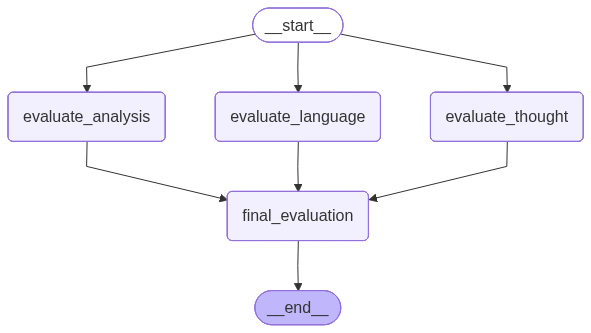

In [46]:
graph = StateGraph(UPSCState)

graph.add_node("evaluate_language", evaluate_language)
graph.add_node("evaluate_analysis", evaluate_analysis)
graph.add_node("evaluate_thought", evaluate_thought)
graph.add_node("final_evaluation", final_evaluation)


# Edges
# Start → Parallel nodes
graph.add_edge(START, "evaluate_language")
graph.add_edge(START, "evaluate_analysis")
graph.add_edge(START, "evaluate_thought")

# All → Final
graph.add_edge("evaluate_language", "final_evaluation")
graph.add_edge("evaluate_analysis", "final_evaluation")
graph.add_edge("evaluate_thought", "final_evaluation")

# End
graph.add_edge("final_evaluation",END)

workflow = graph.compile()
workflow

In [47]:
initial_state = {
    'essay': essay,
    "individual_scores": []
}
workflow.invoke(initial_state)

{'essay': ' \n## The Role of India in Artificial Intelligence\n\nIndia is emerging as one of the most important players in the global artificial intelligence (AI) landscape. With its vast pool of talent, rapidly growing digital infrastructure, and strong government push, India is uniquely positioned to shape how AI is developed and applied—not just for economic growth, but also for social impact.\n\n### 🌱 Foundation: Talent and Scale\n\nOne of India’s biggest strengths is its **human capital**. Every year, millions of students graduate in engineering, data science, and related fields. Institutions like the Indian Institutes of Technology and Indian Institute of Science have been producing highly skilled professionals who contribute to global AI innovation.\n\nAdditionally, India’s large population generates massive amounts of data, which is critical for training AI systems. This combination of **talent + data + scale** gives India a natural advantage.\n\n---\n\n### 🏛️ Government Initia

In [49]:
initial_state = {
    'essay': essay2,
    "individual_scores": []
}
workflow.invoke(initial_state)

{'essay': '\nImportance of India in Artificial Intelligence\nIndia is become a very big player in the world of Artificial Intelligence. Today, many peoples are thinking that AI is the future of technologies, and India have a lot of talent to contribute in this field. The importance of India in AI can be seen in many different ways, from its large population of engineers to the fastly growing startup companies.\n\nFirst main reason is the huge talent pool. India has millions of software engineer who is graduating every years from colleges. This young peoples are very smart in mathematics and codings. Big global tech companies like Google, Microsoft, and others is always hiring from India because the tech talents are very excellent. Indian engineers are not just writing codes, but they are also doing researches in machine learning.\n\nAlso, the startup culture in India are growing very fastly. Cities like Bangalore, which is called the Silicon Valley of India, have so many AI startup. Th